In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [2]:
PROJECT_ROOT = Path("..")

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
DATA_LATENT = PROJECT_ROOT / "data" / "latent"

latent_df = pd.read_parquet(DATA_LATENT / "cnn_vae_latents.parquet")

latent_df.head()

,date,ticker,z_0,z_1,z_2,z_3,z_4,z_5,z_6,z_7
0,2015-09-21,AAPL,0.570995,0.763362,-1.471243,0.018576,-0.514420,0.017025,-1.010024,0.101379
1,2015-09-22,AAPL,0.614655,0.792963,-1.419874,0.016469,-0.512431,0.118162,-1.057017,0.250620
2,2015-09-23,AAPL,0.658633,0.814837,-1.368775,0.034539,-0.484461,0.217649,-1.097016,0.282786
3,2015-09-24,AAPL,0.682787,0.846174,-1.320776,0.003443,-0.486795,0.370344,-1.066684,0.291002
4,2015-09-25,AAPL,0.678678,0.861573,-1.264122,-0.005995,-0.476829,0.467760,-0.986986,0.273219


In [3]:
z_cols = [c for c in latent_df.columns if c.startswith("z_")]

Z = latent_df[z_cols].values

Z.shape

(70080, 8)

In [4]:
latent_df["date"] = pd.to_datetime(latent_df["date"])

print("date range:", latent_df["date"].min(), "->", latent_df["date"].max())
print("n samples:", len(latent_df))
print("n tickers:", latent_df["ticker"].nunique())
print("latent dim:", len(z_cols))

date range: 2015-09-21 00:00:00 -> 2024-12-31 00:00:00
n samples: 70080
n tickers: 30
latent dim: 8


In [5]:
latent_df[z_cols].describe()

,z_0,z_1,z_2,z_3,z_4,z_5,z_6,z_7
count,70080.000000,70080.000000,70080.000000,70080.000000,70080.000000,70080.000000,70080.000000,70080.000000
mean,0.022889,-0.027873,0.011975,-0.019452,-0.096030,-0.015006,-0.011052,0.049494
std,0.997789,1.035482,1.012505,0.983242,1.080530,1.014921,0.979929,0.967197
min,-8.823360,-6.378940,-5.415530,-8.725799,-2.233617,-8.722458,-9.133924,-5.304757
25%,-0.531207,-0.661226,-0.598531,-0.515812,-0.811803,-0.574459,-0.519379,-0.519884
50%,0.044455,-0.123594,-0.088912,0.054657,-0.254883,-0.025600,0.056519,-0.033273
75%,0.595274,0.514724,0.507410,0.555574,0.384341,0.536970,0.563604,0.545461
max,8.308459,5.845548,5.571018,7.542506,8.685370,9.233446,5.590479,6.206614


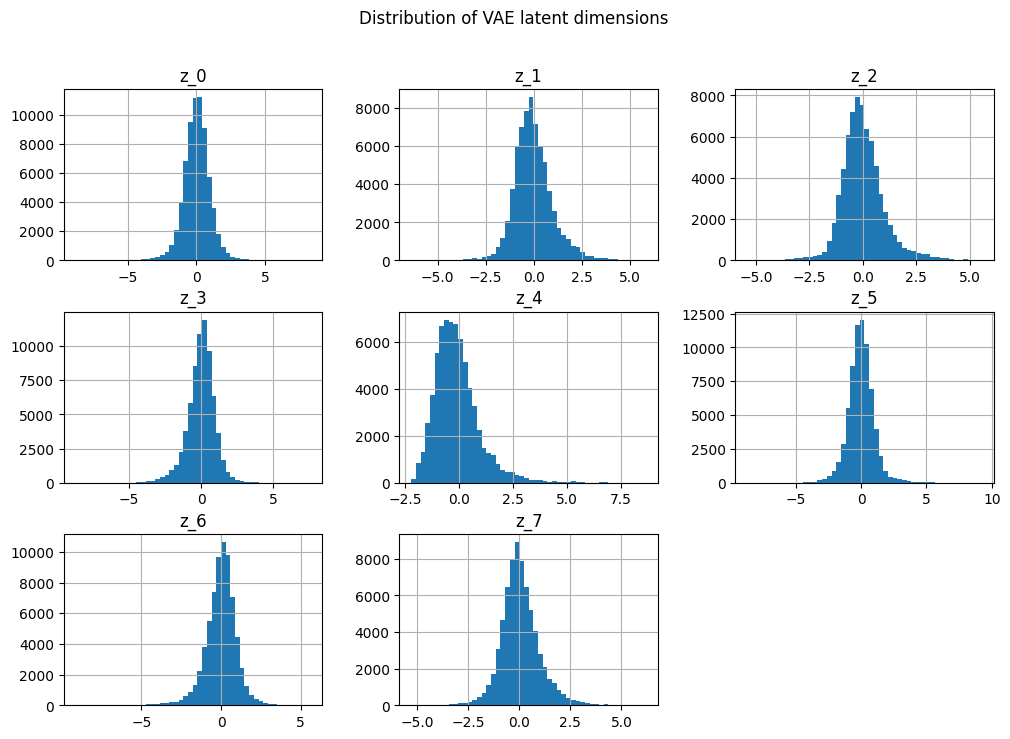

In [6]:
latent_df[z_cols].hist(
    bins=50,
    figsize=(12, 8)
)

plt.suptitle("Distribution of VAE latent dimensions")
plt.show()

In [7]:
pca = PCA(n_components=2)

Z_pca = pca.fit_transform(Z)

latent_df["pc1"] = Z_pca[:, 0]
latent_df["pc2"] = Z_pca[:, 1]

pca.explained_variance_ratio_

/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


array([0.1642645 , 0.14099388], dtype=float32)

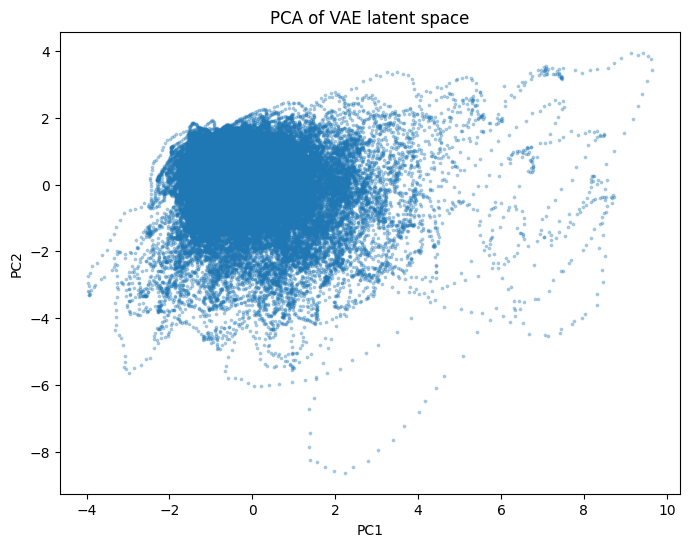

In [8]:
plt.figure(figsize=(8, 6))

plt.scatter(
    latent_df["pc1"],
    latent_df["pc2"],
    s=3,
    alpha=0.3
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of VAE latent space")
plt.show()

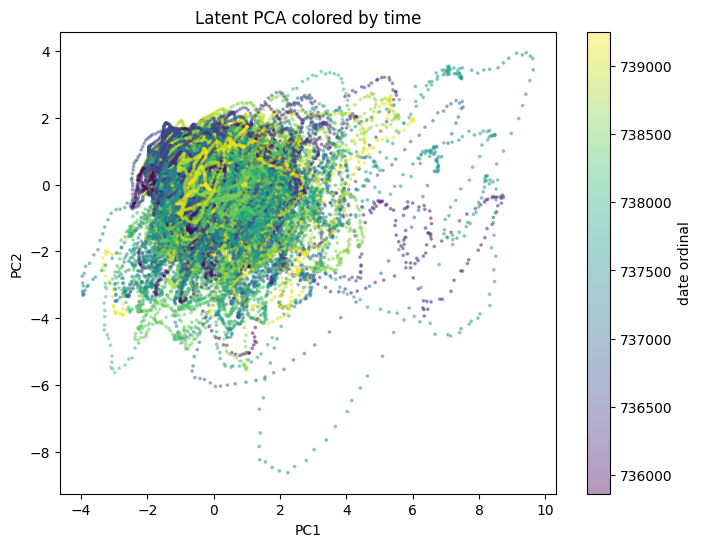

In [9]:
date_numeric = latent_df["date"].map(pd.Timestamp.toordinal)

plt.figure(figsize=(8, 6))

sc = plt.scatter(
    latent_df["pc1"],
    latent_df["pc2"],
    c=date_numeric,
    s=3,
    alpha=0.4
)

plt.colorbar(sc, label="date ordinal")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Latent PCA colored by time")
plt.show()

In [10]:
ticker_latent_mean = (
    latent_df
    .groupby("ticker")[z_cols]
    .mean()
)

ticker_latent_mean.head()

,z_0,z_1,z_2,z_3,z_4,z_5,z_6,z_7
ticker,,,,,,,,
AAPL,0.000987,-0.140261,0.015436,0.010118,-0.094593,-0.000045,0.028189,0.084136
ABBV,0.052106,-0.079126,-0.084078,0.019186,-0.381374,-0.020448,0.040704,-0.016190
ADBE,-0.011751,0.081240,0.057469,-0.034920,0.161181,-0.031331,-0.006699,0.026610
AMD,-0.013843,0.301266,0.729265,-0.324712,1.842931,-0.090030,-0.311486,0.755566
AMZN,-0.003810,-0.002923,0.062311,-0.033383,0.176006,-0.021894,-0.024087,0.109883


In [11]:
ticker_pca = PCA(n_components=2)
ticker_Z_pca = ticker_pca.fit_transform(ticker_latent_mean.values)

ticker_latent_plot = pd.DataFrame(
    ticker_Z_pca,
    index=ticker_latent_mean.index,
    columns=["pc1", "pc2"]
)

ticker_latent_plot.head()

,pc1,pc2
ticker,,
AAPL,-0.012756,-0.111617
ABBV,-0.318444,0.005765
ADBE,0.256133,0.025452
AMD,2.245226,0.056443
AMZN,0.281257,-0.037467


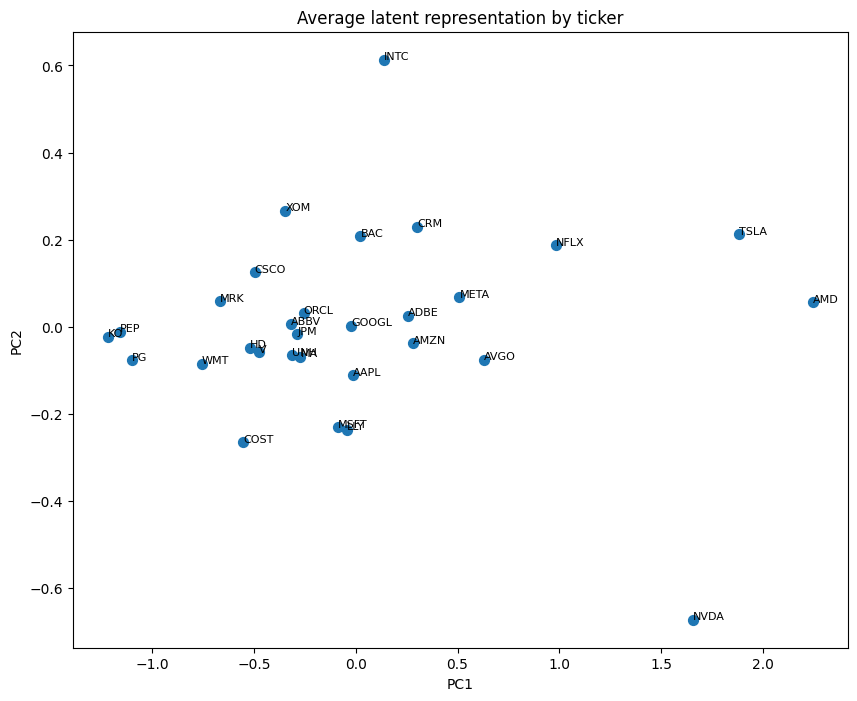

In [12]:
plt.figure(figsize=(10, 8))

plt.scatter(
    ticker_latent_plot["pc1"],
    ticker_latent_plot["pc2"],
    s=50
)

for ticker, row in ticker_latent_plot.iterrows():
    plt.text(row["pc1"], row["pc2"], ticker, fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Average latent representation by ticker")
plt.show()

In [13]:
n_clusters = 4

kmeans = KMeans(
    n_clusters=n_clusters,
    random_state=42,
    n_init="auto"
)

latent_df["cluster"] = kmeans.fit_predict(Z)

/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: Runt

In [14]:
latent_df["cluster"].value_counts().sort_index()

cluster
0    40263
1     7536
2    11141
3    11140
Name: count, dtype: int64

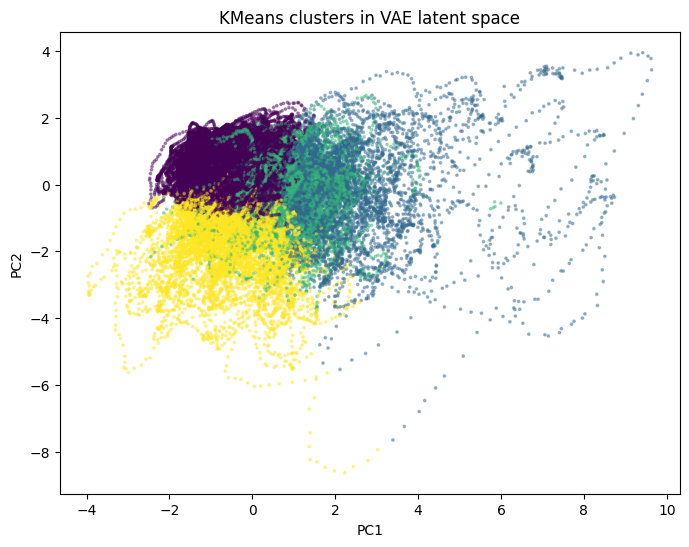

In [15]:
plt.figure(figsize=(8, 6))

plt.scatter(
    latent_df["pc1"],
    latent_df["pc2"],
    c=latent_df["cluster"],
    s=3,
    alpha=0.4
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans clusters in VAE latent space")
plt.show()

In [16]:
cluster_by_date = (
    latent_df
    .groupby(["date", "cluster"])
    .size()
    .unstack(fill_value=0)
)

cluster_share_by_date = cluster_by_date.div(
    cluster_by_date.sum(axis=1),
    axis=0
)

cluster_share_by_date.head()

cluster,0,1,2,3
date,,,,
2015-09-21,0.333333,0.066667,0.1,0.5
2015-09-22,0.333333,0.066667,0.1,0.5
2015-09-23,0.333333,0.066667,0.1,0.5
2015-09-24,0.333333,0.066667,0.1,0.5
2015-09-25,0.333333,0.066667,0.1,0.5


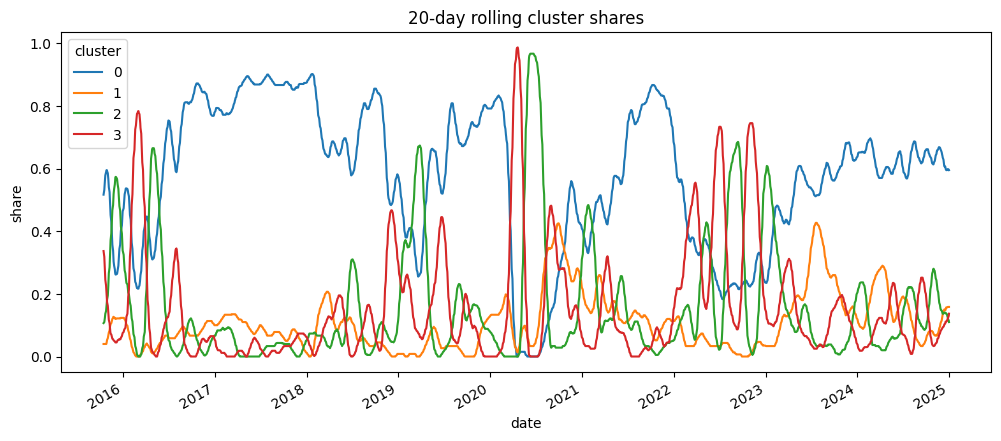

In [17]:
cluster_share_by_date.rolling(20).mean().plot(
    figsize=(12, 5),
    title="20-day rolling cluster shares"
)

plt.ylabel("share")
plt.show()

In [18]:
returns = pd.read_parquet(DATA_PROCESSED / "returns.parquet")
returns.index = pd.to_datetime(returns.index)

returns.head()

Ticker,AAPL,ABBV,ADBE,AMD,AMZN,AVGO,BAC,COST,CRM,CSCO,...,NFLX,NVDA,ORCL,PEP,PG,TSLA,UNH,V,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2015-01-05,-0.028172,-0.018819,-0.004976,-0.003745,-0.020517,-0.015986,-0.029050,-0.011370,-0.018062,-0.019921,...,-0.050897,-0.016891,-0.014024,-0.007518,-0.004754,-0.042041,-0.016472,-0.022074,-0.002911,-0.027362
2015-01-06,0.000094,-0.004950,-0.020145,-0.011278,-0.022833,-0.022743,-0.029919,0.013214,-0.016675,-0.000370,...,-0.017121,-0.030318,-0.010324,-0.007575,-0.004555,0.005664,-0.002018,-0.006444,0.007706,-0.005316
2015-01-07,0.014022,0.040416,0.008223,-0.019011,0.010600,0.027013,0.004745,0.017413,-0.004720,0.009242,...,0.005192,-0.002606,0.000232,0.029242,0.005245,-0.001562,0.010210,0.013398,0.026532,0.010133
2015-01-08,0.038422,0.010459,0.025453,0.011628,0.006836,0.049974,0.020661,0.008592,0.029159,0.007692,...,0.022188,0.037618,0.006026,0.018174,0.011436,-0.001564,0.047733,0.013412,0.021106,0.016645
2015-01-09,0.001073,-0.027355,-0.014811,0.007663,-0.011749,0.010695,-0.017930,-0.015389,-0.007339,0.010179,...,-0.015458,0.004028,-0.000461,-0.006771,-0.009331,-0.018802,-0.009360,-0.014823,-0.012380,-0.001409


In [19]:
returns_next = returns.shift(-1)

future_return_list = []

for _, row in latent_df[["date", "ticker"]].iterrows():
    date = row["date"]
    ticker = row["ticker"]

    try:
        future_return_list.append(returns_next.loc[date, ticker])
    except KeyError:
        future_return_list.append(np.nan)

latent_df["future_return_1d"] = future_return_list

latent_df = latent_df.dropna(subset=["future_return_1d"])

In [20]:
cluster_return_stats = (
    latent_df
    .groupby("cluster")["future_return_1d"]
    .agg(["mean", "std", "count"])
)

cluster_return_stats["sharpe_like"] = (
    cluster_return_stats["mean"] / cluster_return_stats["std"]
)

cluster_return_stats

,mean,std,count,sharpe_like
cluster,,,,
0,0.000747,0.014239,40246,0.052452
1,0.001548,0.027799,7531,0.055677
2,0.001080,0.023271,11140,0.046390
3,0.001463,0.028886,11133,0.050646


In [21]:
corrs = {}

for col in z_cols:
    corrs[col] = latent_df[col].corr(latent_df["future_return_1d"])

corrs = pd.Series(corrs).sort_values()

corrs

z_5   -0.010362
z_2   -0.007937
z_3   -0.001803
z_7   -0.000149
z_6    0.001062
z_1    0.008149
z_0    0.008729
z_4    0.027512
dtype: float64

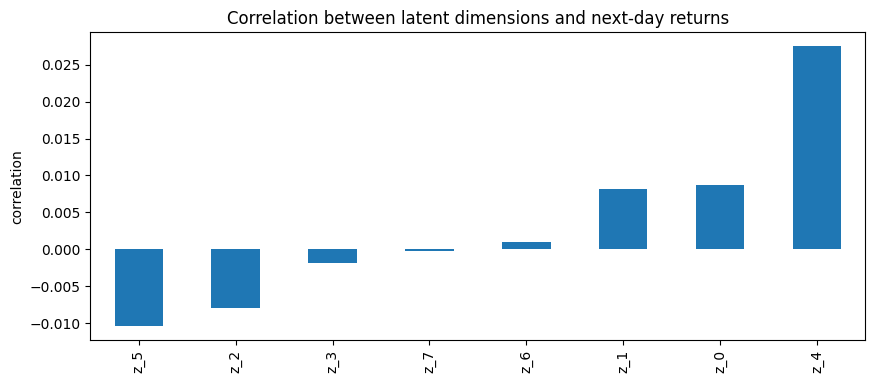

In [22]:
corrs.plot(
    kind="bar",
    figsize=(10, 4),
    title="Correlation between latent dimensions and next-day returns"
)

plt.ylabel("correlation")
plt.show()

In [23]:
latent_df.to_parquet(DATA_LATENT / "fc_vae_latents_analyzed.parquet")

In [24]:
cnn_latent_df = pd.read_parquet(
    DATA_LATENT / "cnn_vae_latents.parquet"
)

In [25]:
cluster_return_stats

,mean,std,count,sharpe_like
cluster,,,,
0,0.000747,0.014239,40246,0.052452
1,0.001548,0.027799,7531,0.055677
2,0.001080,0.023271,11140,0.046390
3,0.001463,0.028886,11133,0.050646


In [26]:
corrs

z_5   -0.010362
z_2   -0.007937
z_3   -0.001803
z_7   -0.000149
z_6    0.001062
z_1    0.008149
z_0    0.008729
z_4    0.027512
dtype: float64

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from pathlib import Path

/Users/holloaron/vae_trading_project/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
